In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

In [65]:
def show_avg_price(dataset):
    data_2020_2025 = dataset[dataset['year'].isin([2020, 2021, 2022, 2023, 2024, 2025])]
    yearly_avg = data_2020_2025.groupby("year")[
        ["Бензин A95","Дизел","Пропан Бутан"]
    ].mean()

    yearly_avg.plot(kind="bar", figsize=(10,6))

    plt.title("Средна годишна цена")
    plt.ylabel("Цена (€)")
    plt.xlabel("Година")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [66]:
def show_trend(dataset, product):
    dataset["start_date"] = pd.to_datetime(dataset["start_date"])
    dataset = dataset.sort_values("start_date")

    x = dataset["start_date"]
    y = dataset[product]

    plt.figure(figsize=(10,5))

    plt.plot(x, y, color="#4C72B0", alpha=0.4, linewidth=1.5, label="Седмична цена")

    max_idx = y.idxmax()
    min_idx = y.idxmin()

    plt.scatter(
        dataset.loc[max_idx, "start_date"],
        y.max(),
        color="darkred",
        s=100,
        zorder=5,
        label="Най-висока цена"
    )

    plt.scatter(
        dataset.loc[min_idx, "start_date"],
        y.min(),
        color="darkgreen",
        s=100,
        zorder=5,
        label="Най-ниска цена"
    )

    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.grid(axis='y', alpha=0.3)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.title(f"Движение на цените на {product} (2020–2025)", fontsize=18, weight='bold')
    plt.xlabel("Година", fontsize=13)
    plt.ylabel("Цена (€ / л)", fontsize=13)

    plt.legend()
    plt.tight_layout()
    plt.show()

In [67]:
data = pd.read_csv('../datasets/fuelo_master_dataset.csv')
data['month'] = data['start_date'].str.split('-').apply(lambda x: x[1])

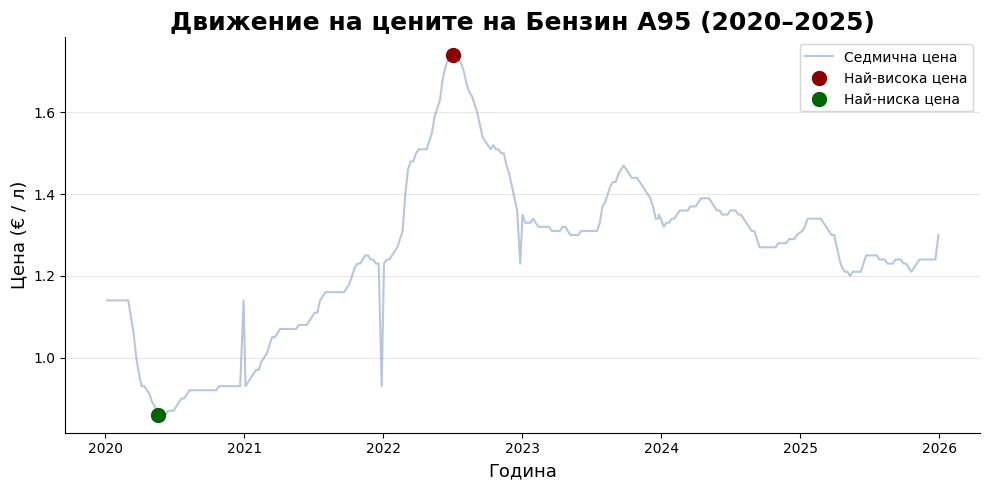

In [73]:
show_trend(data_2020_2025, 'Бензин A95')

През 2020 г. цените на бензин A95 спадат до най-ниското си ниво за разглеждания период – под 0.90 €/л. Този спад е пряко свързан с COVID-19 пандемията, ограничителните мерки и рязкото намаляване на транспортната активност, което доведе до свито търсене на горива в глобален мащаб.

През 2021 г. започва постепенно възстановяване, подкрепено от икономическото оживление и възстановяването на потреблението. Най-сериозният ценови пик обаче се наблюдава през 2022 г., когато бензинът достига приблизително 1.70–1.75 €/л. Това е най-високата стойност за периода и е пряко свързана с войната в Украйна, енергийната несигурност в Европа и сътресенията на международните суровинни пазари.

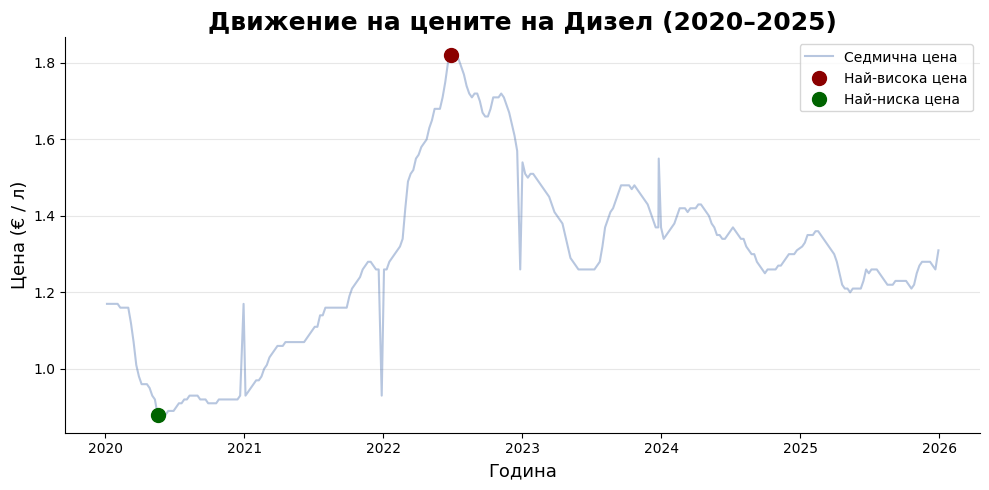

In [74]:
show_trend(data_2020_2025, 'Дизел')

Подобна динамика се наблюдава и при дизела, което потвърждава силната зависимост на горивния пазар от глобалните икономически и геополитически процеси.

През 2020 г. и при дизела се отчита рязък спад – до нива под 0.90 €/л., вследствие на ограниченото движение и свитото търсене по време на пандемията. През 2021 г. започва възстановяване, а през 2022 г. цената достига своя връх – над 1.80 €/л., под влияние на войната в Украйна, нарушените вериги на доставки и нестабилността на енергийните пазари в Европа.

След 2022 г. при дизела се наблюдава постепенна корекция и стабилизиране. В периода 2023–2025 г. цените се движат в по-умерен диапазон, без достигане на нови екстремни стойности.


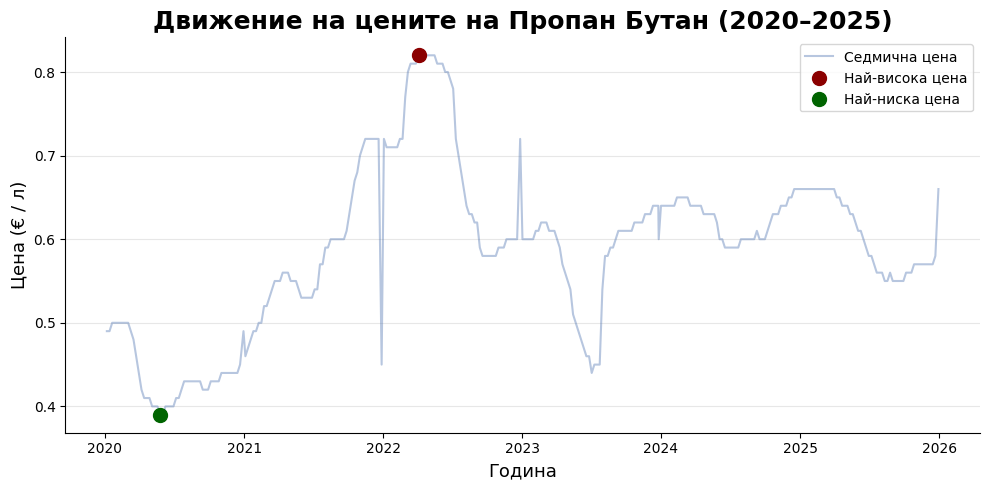

In [75]:
show_trend(data_2020_2025, 'Пропан Бутан')

Сходна, макар и по-умерена динамика се наблюдава и при пропан-бутана. През 2020 г. цените спадат до най-ниските си нива – около 0.40 €/л., отново под въздействието на пандемията и ограничената икономическа активност. През 2021 г. започва възходяща тенденция, която достига своя пик през 2022 г. – над 0.80 €/л., в контекста на енергийната криза и нестабилността на суровинните пазари.

В периода 2023–2025 г. цените на пропан-бутана се стабилизират в по-нисък диапазон спрямо върховете от 2022 г., като не се наблюдават нови екстремни стойности.

В обобщение, движението на трите основни горива в периода 2020–2025 г. ясно показва цикличност – спад по време на COVID-19, рязък скок вследствие на войната в Украйна и последваща нормализация. Данните потвърждават, че глобалните здравни и геополитически събития оказват пряко и осезаемо влияние върху цените на горивата и разходите за потребителите и бизнеса.

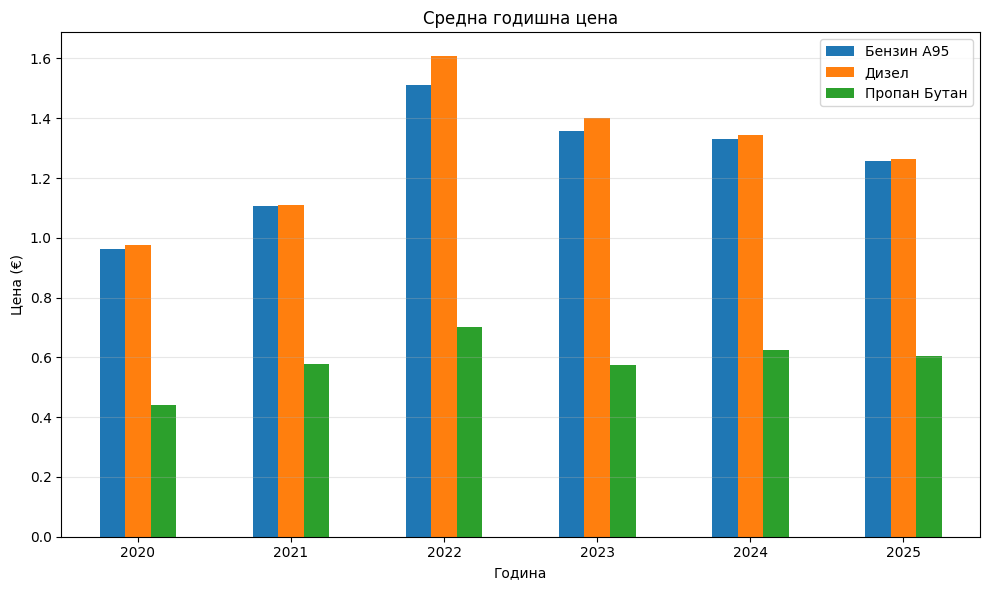

In [68]:
show_avg_price(data)

След динамиката на седмичните движения, средните годишни цени дават по-ясна картина за общата тенденция в периода 2020–2025 г.

През 2020 г. и трите вида горива отбелязват най-ниските си средни стойности за разглеждания период – пряк резултат от COVID-19 пандемията и свитото потребление. През 2021 г. се наблюдава възстановяване, а през 2022 г. е отчетен най-силният ръст. Средната годишна цена достига своя максимум именно тогава – приблизително 1.50 €/л. за бензин A95, около 1.60 €/л. за дизел и близо 0.70 €/л. за пропан-бутан. Това ясно отразява ефекта от войната в Украйна и енергийната криза в Европа.

След 2022 г. следва корекция. През 2023 г. цените започват да се понижават, а през 2024–2025 г. се стабилизират в по-умерен диапазон. Въпреки това средните стойности остават по-високи спрямо предпандемичните нива от 2020 г., което показва, че пазарът не се връща напълно към старите ценови равнища.

Графиката ясно обобщава цикъла на периода: спад през пандемията, пик по време на енергийната криза и последваща постепенна нормализация.